# Общее функциональное подпространство между изображениями

## Главный результат

На независимом holdout найдено небольшое пространство, общее между изображениями:

- pooled rank-32 покрывает 88.4% чувствительности якобианов;
- оно объясняет 92.8% наблюдаемого линейного score-эффекта;
- в него попадает лишь 1.38% энергии локальной patch-delta;
- вычитание этой проекции возвращает 73.1% исходно скрытых объектов;
- перенос пространства между успешными и неуспешными исходами даёт 73.1% recovery.

Это сильное свидетельство, что функциональная компонента **не полностью индивидуальна
для изображения**. Однако это пока white-box clean–patched анализ одного патча и одной
модели, а не готовая защита.

## 1. Что именно проверяется

Для каждого кандидата целевого объекта берётся каноническое окно $5\times5$ на входе
class-ветви Detect. В одинаковых координатах `channel × relative_y × relative_x`
сохраняются:

- локальная patch-delta;
- локальный градиент score кандидата;
- их first-order функциональная проекция.

Пространства расширяются по степени обобщения:

| setting | Откуда строится базис | На чём проверяется |
|---|---|---|
| `oracle_image` | кандидаты того же holdout-изображения | то же изображение |
| `same_group` | train той же routing-группы | новые изображения группы |
| `same_outcome` | все train с тем же visible/hidden outcome | новые изображения outcome |
| `pooled_all` | все train-группы | весь holdout |
| `cross_outcome` | только противоположный outcome | unseen outcome |
| `random` | случайные ортогональные направления | весь holdout |

`sensitivity` строится по нормированным градиентам и преимущественно характеризует
модель. `attack` взвешивает те же направления фактическим clean→patched эффектом и
добавляет характеристику данного патча.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RUN = Path(r"/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/shared_functional_space_outputs/shared_space_0e8b77cb38660969")
summary = json.loads((RUN / "summary.json").read_text())
analytic = pd.read_csv(RUN / "analytic_summary.csv")
causal = pd.read_csv(RUN / "causal_summary.csv")
causal_rows = pd.read_csv(RUN / "causal_rows.csv")
split = pd.read_csv(RUN / "split.csv")

sns.set_theme(style="whitegrid", context="notebook")
print({
    "examples": summary["n_examples"],
    "train": summary["n_train"],
    "holdout": summary["n_test"],
    "elapsed_min": round(summary["elapsed_seconds"] / 60, 2),
})
display(pd.crosstab(split.analysis_group, split.split))

{'examples': 400, 'train': 240, 'holdout': 160, 'elapsed_min': 7.18}


split,test,train
analysis_group,,
hidden_low_conf_match,40,60
hidden_no_iou_match,40,60
visible_non_target_winner,40,60
visible_target_winner,40,60


Выборка сбалансирована: по 60 train и 40 holdout изображений из каждой
routing-группы. Все базисы, кроме `oracle_image`, строятся без использования holdout.

## 2. Есть ли общее пространство чувствительности?

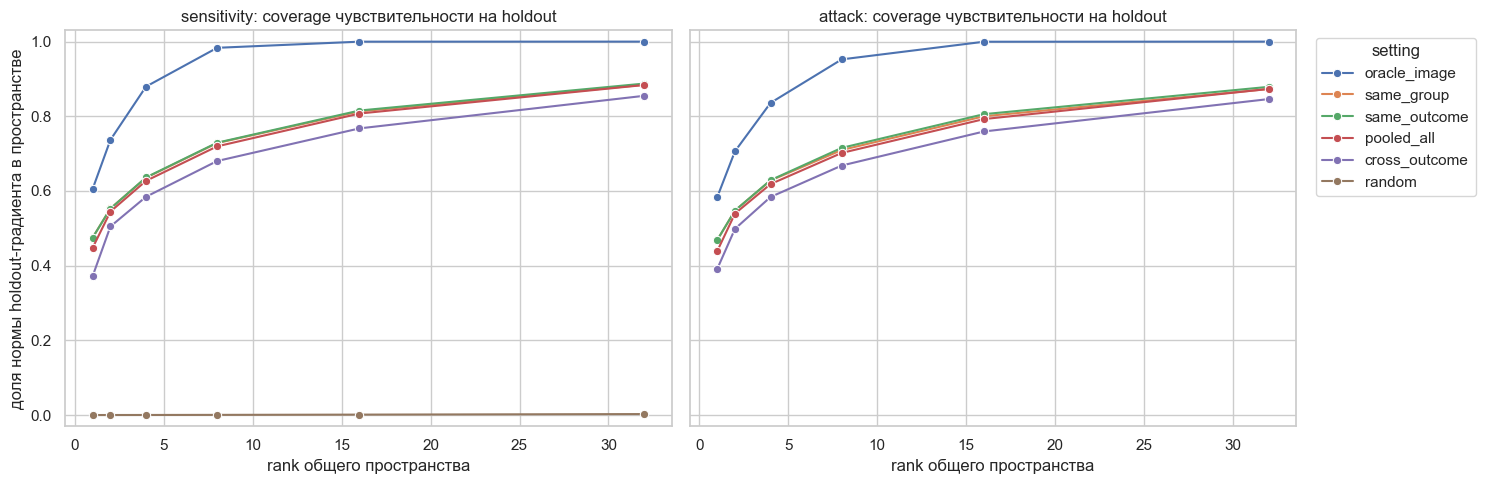

In [2]:
settings = ["oracle_image", "same_group", "same_outcome",
            "pooled_all", "cross_outcome", "random"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, family in zip(axes, ["sensitivity", "attack"]):
    frame = analytic[analytic.family.eq(family)]
    sns.lineplot(
        data=frame, x="rank", y="mean_gradient_coverage",
        hue="setting", hue_order=settings, marker="o", ax=ax,
    )
    ax.set_title(f"{family}: coverage чувствительности на holdout")
    ax.set_xlabel("rank общего пространства")
    ax.set_ylabel("доля нормы holdout-градиента в пространстве")
    ax.set_ylim(-0.03, 1.03)
axes[0].legend_.remove()
axes[1].legend(title="setting", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

На rank-32 единый `pooled_all` sensitivity-базис покрывает
88.4% holdout-чувствительности. Даже
`cross_outcome` attack-базис покрывает 84.6%, тогда как
случайные 32 направления — только 0.26%.

Следовательно, совпадение нельзя объяснить одной размерностью базиса: локальные
якобианы новых изображений действительно сосредоточены около общего пространства.

## 3. Объясняет ли пространство эффект конкретного патча?

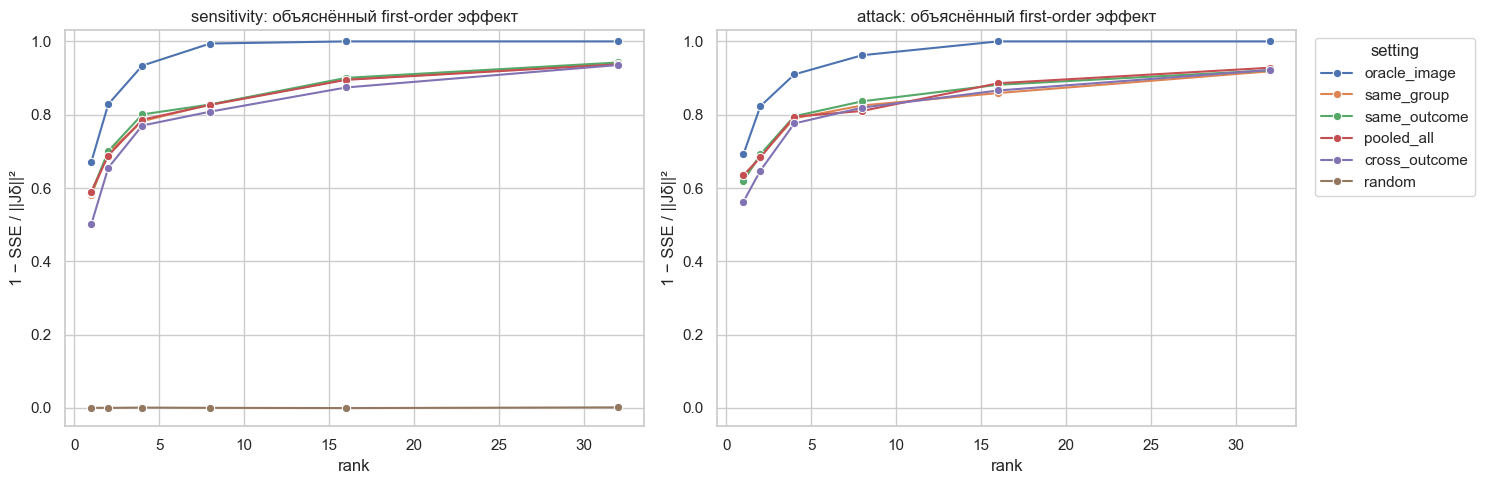

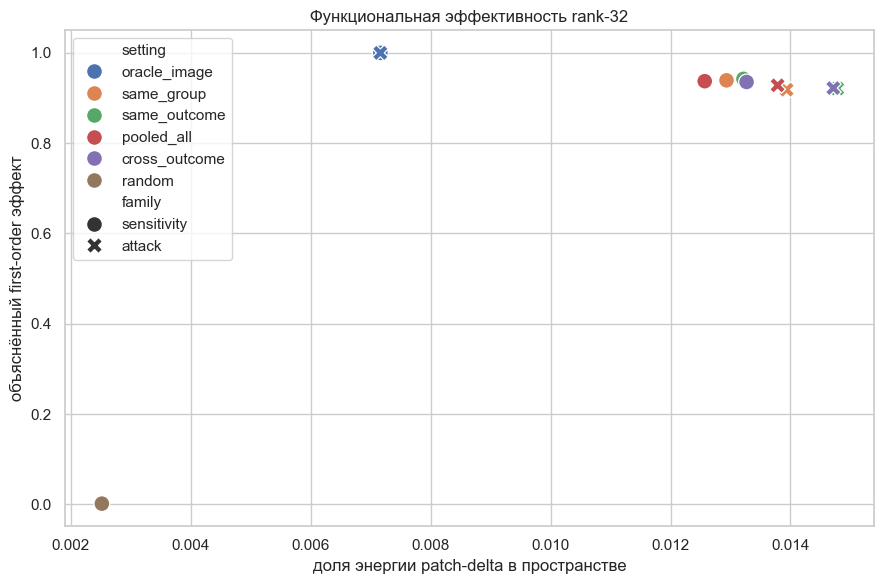

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, family in zip(axes, ["sensitivity", "attack"]):
    frame = analytic[analytic.family.eq(family)]
    sns.lineplot(
        data=frame, x="rank", y="effect_r2_zero",
        hue="setting", hue_order=settings, marker="o", ax=ax,
    )
    ax.set_title(f"{family}: объяснённый first-order эффект")
    ax.set_xlabel("rank")
    ax.set_ylabel("1 − SSE / ||Jδ||²")
    ax.set_ylim(-0.05, 1.03)
axes[0].legend_.remove()
axes[1].legend(title="setting", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

rank32 = analytic[analytic["rank"].eq(32)].copy()
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rank32, x="mean_delta_energy_fraction", y="effect_r2_zero",
    hue="setting", style="family", s=130,
)
plt.xlabel("доля энергии patch-delta в пространстве")
plt.ylabel("объяснённый first-order эффект")
plt.title("Функциональная эффективность rank-32")
plt.tight_layout()
plt.show()

`pooled_all/attack` объясняет 92.8% линейного
эффекта при 1.38% энергии patch-delta. Значит, общий
базис описывает не только абстрактную чувствительность модели: реальный патч
систематически возбуждает эти направления на новых изображениях.

`attack` немного эффективнее `sensitivity` на малых rank, но к rank-32 различие
небольшое. Основная геометрия пространства, вероятно, задаётся моделью; патч
преимущественно определяет веса внутри неё.

## 4. Причинная проверка на holdout

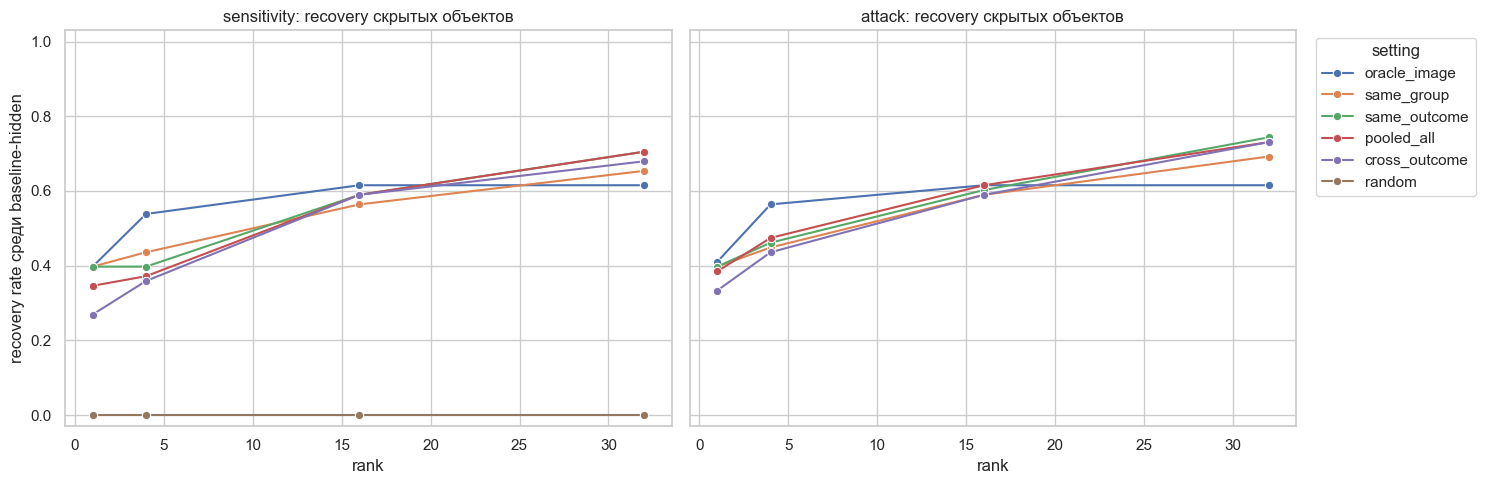

In [4]:
plot = causal[~causal.family.eq("none")].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, family in zip(axes, ["sensitivity", "attack"]):
    frame = plot[plot.family.eq(family)]
    sns.lineplot(
        data=frame, x="rank", y="recovery_rate",
        hue="setting", hue_order=settings, marker="o", ax=ax,
    )
    ax.set_title(f"{family}: recovery скрытых объектов")
    ax.set_xlabel("rank")
    ax.set_ylabel("recovery rate среди baseline-hidden")
    ax.set_ylim(-0.03, 1.03)
axes[0].legend_.remove()
axes[1].legend(title="setting", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Среди 78 baseline-hidden случаев rank-32:

- `pooled_all/attack` восстанавливает 73.1%;
- `cross_outcome/attack` — 73.1%;
- `pooled_all/sensitivity` — 70.5%;
- случайный базис — 0%.

То есть пространство переносится не только по линейной метрике: его вычитание
причинно меняет итог детектора. При этом здесь `damage=0` означает отсутствие
ухудшения **у patched, но уже видимых** объектов. Чистые изображения в этой
проверке не модифицировались, поэтому это ещё не оценка false-positive damage
готовой защиты.

## 5. Где остаются неудачи?

,analysis_group,n,recovery_rate,mean_pre_target_conf
0,hidden_low_conf_match,40,1.000000,0.546386
1,hidden_no_iou_match,38,0.447368,0.298349


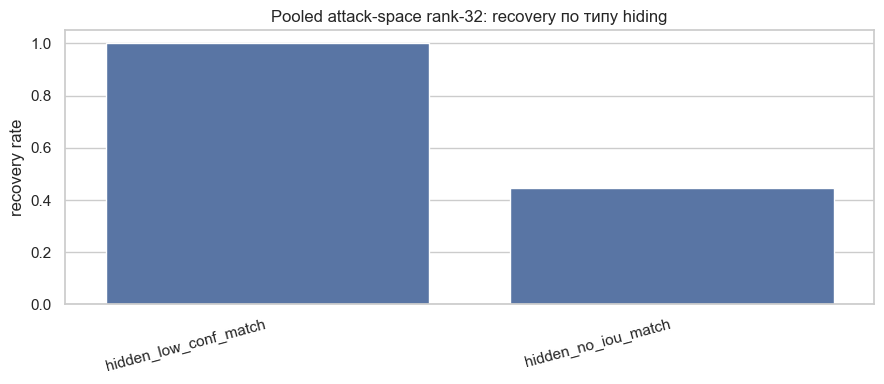

In [5]:
chosen = causal_rows[
    causal_rows.family.eq("attack")
    & causal_rows.setting.eq("pooled_all")
    & causal_rows["rank"].eq(32)
].copy()
hidden = chosen[chosen.baseline_hidden.astype(bool)]
by_group = hidden.groupby("analysis_group", as_index=False).agg(
    n=("example_id", "nunique"),
    recovery_rate=("target_detected", "mean"),
    mean_pre_target_conf=("pre_target_conf", "mean"),
)
display(by_group)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=by_group, x="analysis_group", y="recovery_rate", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_ylabel("recovery rate")
ax.set_title("Pooled attack-space rank-32: recovery по типу hiding")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

Score-ориентированное пространство возвращает
100.0% случаев
`hidden_low_conf_match`, но лишь
44.7%
`hidden_no_iou_match`.

Это согласуется с постановкой: якобиан и базис строятся по class-score ветви.
Оставшийся потолок связан прежде всего с группой, где после патча нет подходящего
IoU-кандидата, то есть score-repair сам по себе недостаточен.

## 6. Неожиданный результат и ограничение интерпретации

`oracle_image` на rank-16/32 объясняет практически 100% локального линейного
эффекта, но причинно восстанавливает только 61.5% —
меньше общего пространства (73.1%).

Это не означает, что общий базис «точнее oracle». У shared-проекции больше
энергии, а вмешательство проходит через нелинейную class-head и перекрывающиеся
окна кандидатов. Поэтому оно может сильнее переисправлять score. Получены два
разных утверждения:

1. **Линейное:** индивидуальный row space полностью описывает $J\delta$.
2. **Причинное конечное вмешательство:** наиболее полная линейная проекция не
   обязана давать лучший post-NMS recovery.

Перед заявлением о superiority shared-repair нужен прямой energy-matched
контроль. Случайный rank-32 базис dimension-matched, но естественно забирает
гораздо меньше энергии дельты.

## 7. Итог

Подтверждено общее низкоразмерное score-функциональное пространство:

- оно строится только по train-изображениям;
- переносится на новые изображения;
- почти не зависит от visible/hidden outcome;
- существенно превосходит случайный базис;
- содержит около 1% энергии дельты, но большую часть её score-эффекта;
- его удаление причинно возвращает большую часть low-confidence hiding.

Пока нельзя утверждать, что найден универсальный механизм любых патчей:
использованы одна модель, один патч и фактически только P5. Следующий строгий
эксперимент — построить базис на одном патче и без дообучения проверить его на
нескольких независимо обученных патчах, добавив energy-matched random/top-abs
контроли. Только после этого имеет смысл использовать общий базис как objective
нового патча или как prior защиты.